In [62]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.dates as mdates

In [2]:
df = pd.read_csv("Sample - Superstore.csv", encoding="ISO-8859-1")

In [3]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [4]:
df.shape

(9994, 21)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9989    False
9990    False
9991    False
9992    False
9993    False
Length: 9994, dtype: bool

In [7]:
df[df.duplicated(keep=False)]
# Luckily, there are no duplicated rows. We can move on with the rest of the analysis.

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit


In [8]:
# Separating categorical and numerical features.
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

print("Categorial columns: ", cat_col)
print("Numerical data: ", num_col)

Categorial columns:  ['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name']
Numerical data:  ['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit']


In [9]:
df[cat_col].nunique()
# We can't make comments for the ones that have very few unique values. They might still have very big impact.
# However, it seems like the "Country" doesn't affect profit, because there's only one.

Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
dtype: int64

In [10]:
round((df.isnull().sum()/df.shape[0]) * 100, 2)
# We have no null values, so we can move on with the analysis.

Row ID           0.0
Order ID         0.0
Order Date       0.0
Ship Date        0.0
Ship Mode        0.0
Customer ID      0.0
Customer Name    0.0
Segment          0.0
Country          0.0
City             0.0
State            0.0
Postal Code      0.0
Region           0.0
Product ID       0.0
Category         0.0
Sub-Category     0.0
Product Name     0.0
Sales            0.0
Quantity         0.0
Discount         0.0
Profit           0.0
dtype: float64

Text(0.5, 1.0, 'Correlation Matrix of Numerical Features')

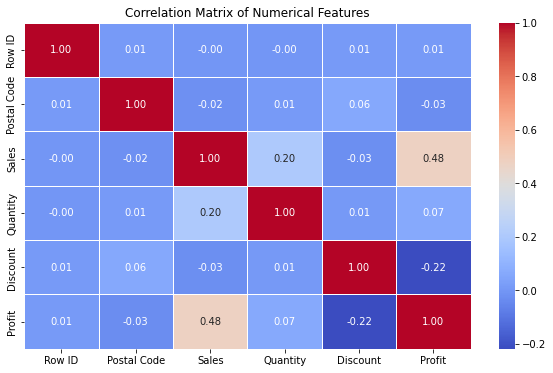

In [11]:
matrix = df[num_col].corr()

plt.figure(figsize = (10,6))
sns.heatmap(matrix, annot = True, cmap = 'coolwarm', fmt = '.2f', linewidths = 0.5)
plt.title("Correlation Matrix of Numerical Features")

# We can see that there is a strong correlation between sales and profit, which makes sense.
# There's also negative correlation between discount and profit, which also makes sense. Lesser the price, lesser the profit.
# However, there is no correlation between quantity and profit, which is interesting. It means that the number of items sold doesn't affect the profit. This might be because of the discount, which affects the profit more than the quantity.


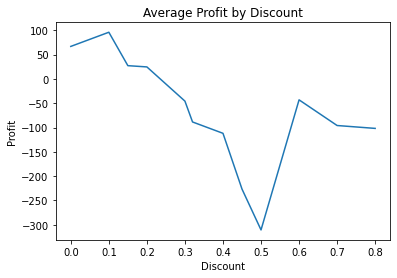

In [12]:
discount_profit = df.groupby("Discount")["Profit"].mean().reset_index()

sns.lineplot(data=discount_profit, x="Discount", y="Profit")
plt.title("Average Profit by Discount")
plt.show()

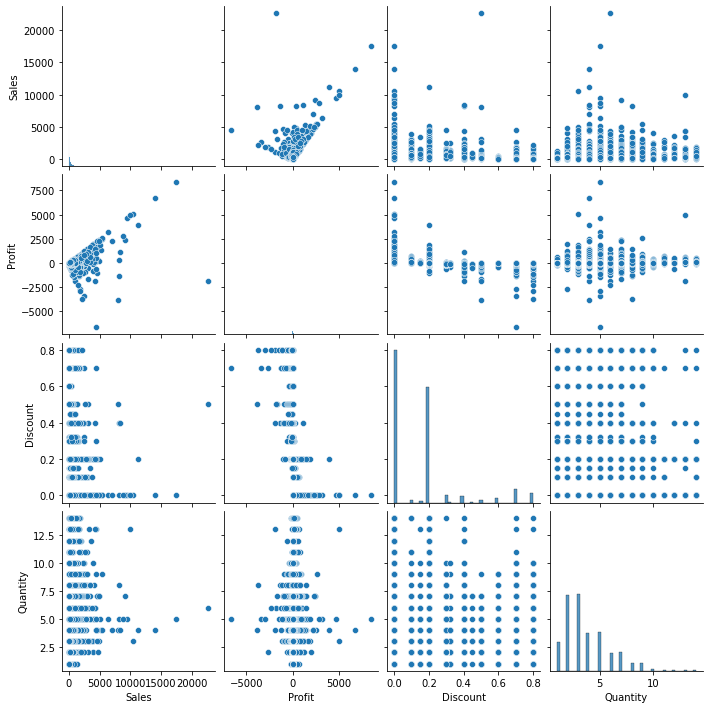

In [13]:
sns.pairplot(df[["Sales", "Profit", "Discount", "Quantity"]])
# A more visual way to see the relationship between important numerical features.

In [14]:
exclude = ["Order ID", "Customer ID", "Product ID", "Customer Name", "Product Name"]
cat_col = [col for col in cat_col if col not in exclude]

# These categorical values don't add much value to our analysis right now. We can move on without them and start analyzing the rest.


In [15]:
cat_col

['Order Date',
 'Ship Date',
 'Ship Mode',
 'Segment',
 'Country',
 'City',
 'State',
 'Region',
 'Category',
 'Sub-Category']

In [16]:
feature_summary = {}

for col in cat_col:
    grouped = df.groupby(col)["Profit"]
    
    summary = grouped.agg(
        avg_profit="mean",
        median_profit="median",
        total_profit="sum",
        orders="count",
        loss_rate=lambda x: (x < 0).mean()
    )
    
    # measure how different groups are
    summary["avg_profit_diff"] = summary["avg_profit"] - summary["avg_profit"].mean()
    
    feature_summary[col] = summary

In [17]:
feature_summary['Ship Mode']

# We can check each categorical feature like this and see how it affects the profit.

,avg_profit,median_profit,total_profit,orders,loss_rate,avg_profit_diff
Ship Mode,,,,,,
First Class,31.839948,8.7789,48969.8399,1538,0.190507,2.305734
Same Day,29.266591,8.0270,15891.7589,543,0.180479,-0.267623
Second Class,29.535545,9.4284,57446.6354,1945,0.157841,0.001332
Standard Class,27.494770,8.3010,164088.7875,5968,0.196548,-2.039444


In [18]:
# But! We can also check the overall impact of each categorical value by looking at the standard deviation of the average profit for each group.

impact = {}
for col in cat_col:
    group_means = df.groupby(col)["Profit"].mean()
    impact[col] = group_means.std()

In [19]:
impact = pd.Series(impact).sort_values(ascending=False)
impact

Sub-Category    195.951129
Ship Date       107.428912
Order Date      102.773182
City             67.623876
State            51.200953
Category         37.541214
Region            7.550268
Segment           4.007379
Ship Mode         1.783944
Country                NaN
dtype: float64

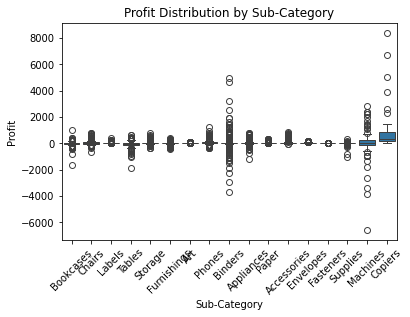

In [20]:
#Categorical features that impact the profit: sub-category, city, state and category
#Medium impact:region, segment and ship mode
#There's only one country and ship/order dates can be excluded for now as we are not doing time series analysis

top = impact.index[0]

sns.boxplot(data=df, x=top, y="Profit")
plt.xticks(rotation=45)
plt.title(f"Profit Distribution by {top}")
plt.show()

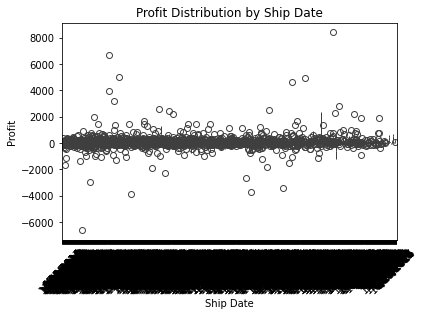

In [21]:
top1 = impact.index[1]

sns.boxplot(data=df, x=top1, y="Profit")
plt.xticks(rotation=45)
plt.title(f"Profit Distribution by {top1}")
plt.show()

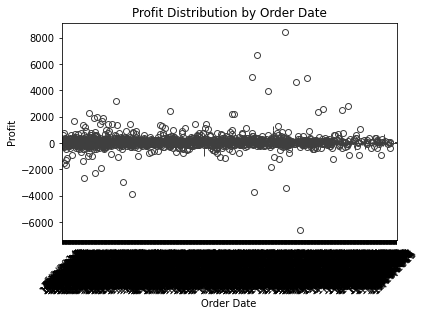

In [22]:
top2 = impact.index[2]

sns.boxplot(data=df, x=top2, y="Profit")
plt.xticks(rotation=45)
plt.title(f"Profit Distribution by {top2}")
plt.show()

In [23]:
exclude_more = ["Order Date", "Ship Date", "City", "State", "Country"]
cat_col = [c for c in cat_col if c not in exclude_more]

In [24]:
cat_col

['Ship Mode', 'Segment', 'Region', 'Category', 'Sub-Category']

# Are some products more profitable than others?

In [25]:
# How often does each product lose the money.
loss = df.groupby("Sub-Category").agg(
    total_profit=("Profit", "sum"),
    avg_profit=("Profit", "mean"),
    loss_rate=("Profit", lambda x: (x < 0).mean() * 100)
).sort_values("total_profit")


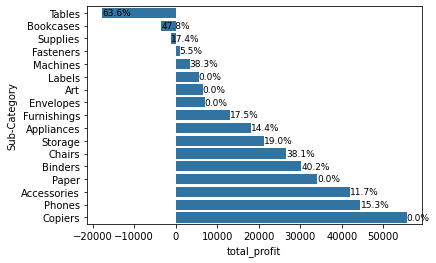

In [26]:
# We can clearly see that the tables are losing the money. There's slight loss for bookcases and supplies.
# We can also extract the top performing ones. 

ax = sns.barplot(data=loss.reset_index(), x="total_profit", y="Sub-Category")

for i, bar in enumerate(ax.patches):
    width = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2
    loss_rate = loss.iloc[i]["loss_rate"]  # loss is indexed by Sub-Category, order matches bar order
    ax.text(width + 0.5, y, f"{loss_rate:.1f}%", va='center', ha='left', fontsize=9)

plt.show()

In [27]:
subcategory_summary = df.groupby("Sub-Category").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_profit=("Profit", "mean"),
    orders=("Order ID", "count"),
    loss_rate=("Profit", lambda x: (x < 0).mean() * 100)
)

subcategory_summary["profit_margin"] = subcategory_summary["total_profit"] / subcategory_summary["total_sales"]
subcategory_summary = subcategory_summary.sort_values("total_profit")

In [28]:
print("Top sub-categories by total profit:")
subcategory_summary[["total_sales", "total_profit", "avg_profit", "orders", "loss_rate", "profit_margin"]].sort_values(
    "total_profit", ascending=False
).head(10)

Top sub-categories by total profit:


,total_sales,total_profit,avg_profit,orders,loss_rate,profit_margin
Sub-Category,,,,,,
Copiers,149528.030,55617.8249,817.909190,68,0.000000,0.371956
Phones,330007.054,44515.7306,50.073938,889,15.298088,0.134893
Accessories,167380.318,41936.6357,54.111788,775,11.741935,0.250547
Paper,78479.206,34053.5693,24.856620,1370,0.000000,0.433918
Binders,203412.733,30221.7633,19.843574,1523,40.249508,0.148574
Chairs,328449.103,26590.1663,43.095894,617,38.087520,0.080957
Storage,223843.608,21278.8264,25.152277,846,19.030733,0.095061
Appliances,107532.161,18138.0054,38.922758,466,14.377682,0.168675
Furnishings,91705.164,13059.1436,13.645918,957,17.450366,0.142404


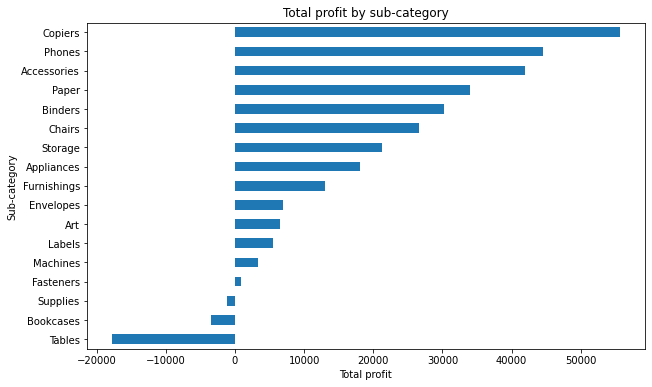

In [29]:
# It seems like profit and loss rate correspond to each other.

plt.figure(figsize=(10, 6))
subcategory_summary["total_profit"].plot(kind="barh")
plt.title("Total profit by sub-category")
plt.xlabel("Total profit")
plt.ylabel("Sub-category")
plt.show()

In [30]:
top_subcats = subcategory_summary.sort_values("total_profit", ascending=False).head(10)
top_subcats

,total_sales,total_profit,avg_profit,orders,loss_rate,profit_margin
Sub-Category,,,,,,
Copiers,149528.030,55617.8249,817.909190,68,0.000000,0.371956
Phones,330007.054,44515.7306,50.073938,889,15.298088,0.134893
Accessories,167380.318,41936.6357,54.111788,775,11.741935,0.250547
Paper,78479.206,34053.5693,24.856620,1370,0.000000,0.433918
Binders,203412.733,30221.7633,19.843574,1523,40.249508,0.148574
Chairs,328449.103,26590.1663,43.095894,617,38.087520,0.080957
Storage,223843.608,21278.8264,25.152277,846,19.030733,0.095061
Appliances,107532.161,18138.0054,38.922758,466,14.377682,0.168675
Furnishings,91705.164,13059.1436,13.645918,957,17.450366,0.142404


# Are there any cities/states that have consistently generated more loss than profit? 

In [31]:
state_summary = df.groupby("State").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_profit=("Profit", "mean"),
    orders=("Order ID", "count")
)


In [32]:
state_summary["profit_margin"] = state_summary["total_profit"] / state_summary["total_sales"]
state_summary["loss_rate"] = df.groupby("State")["Profit"].apply(lambda x: (x < 0).mean() * 100)

state_summary_filtered = state_summary[state_summary["orders"] >= 30]

In [33]:
print("Top performing states")
state_summary_filtered.sort_values("total_profit", ascending=False).head(10)
# Some states contribute strongly to profit, while others underperform. See the top bottom states.
# This suggests profitability differs across geographic markets, not just across products.

Top performing states


,total_sales,total_profit,avg_profit,orders,profit_margin,loss_rate
State,,,,,,
California,457687.6315,76381.3871,38.171608,2001,0.166885,5.247376
New York,310876.2710,74038.5486,65.637011,1128,0.238161,4.166667
Washington,138641.2700,33402.6517,66.013146,506,0.240929,3.359684
Michigan,76269.6140,24463.1876,95.934069,255,0.320746,0.000000
Virginia,70636.7200,18597.9504,83.026564,224,0.263290,0.000000
Indiana,53555.3600,18382.9363,123.375411,149,0.343251,0.000000
Georgia,49095.8400,16250.0433,88.315453,184,0.330986,0.000000
Kentucky,36591.7500,11199.6966,80.573357,139,0.306072,0.000000
Minnesota,29863.1500,10823.1874,121.608847,89,0.362426,0.000000


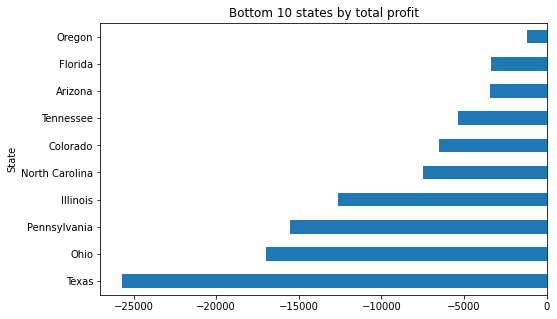

In [34]:
state_summary[state_summary["orders"] >= 30]["total_profit"].sort_values().head(10).plot(
    kind="barh", figsize=(8,5), title="Bottom 10 states by total profit"
)
plt.show()

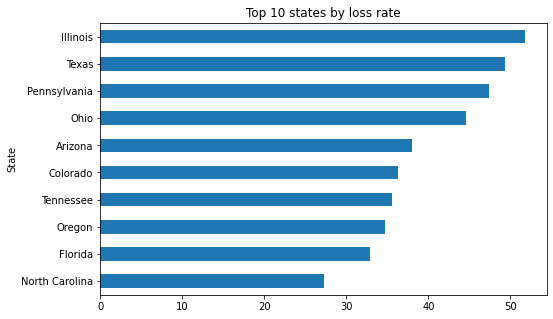

In [35]:
state_summary_filtered["loss_rate"].sort_values(ascending=False).head(10).sort_values().plot(
    kind="barh", figsize=(8,5), title="Top 10 states by loss rate"
)
plt.show()

In [36]:
# Top cities

top_cities = df["City"].value_counts().head(15).index

city_summary = df.groupby("City").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    avg_profit=("Profit", "mean"),
    orders=("Order ID", "count")
)

city_summary.loc[top_cities]

# City-level results are noisier, but they still help identify locations with persistent weak performance.
# A minimum order threshold helps keep the analysis more reliable.

,total_sales,total_profit,avg_profit,orders
New York City,256368.1610,62036.9837,67.799982,915
Los Angeles,175851.3410,30440.7579,40.750680,747
Philadelphia,109077.0130,-13837.7674,-25.768654,537
San Francisco,112669.0920,17507.3854,34.328207,510
Seattle,119540.7420,29156.0967,68.121721,428
Houston,64504.7604,-10153.5485,-26.932489,377
Chicago,48539.5410,-6654.5688,-21.192894,314
Columbus,38706.2430,5897.1013,26.563519,222
San Diego,47521.0290,6377.1960,37.512918,170
Springfield,43054.3420,6200.6974,38.041088,163


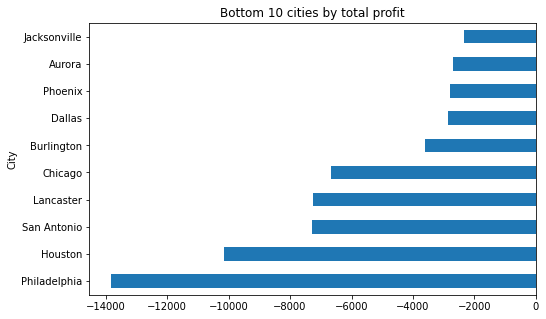

In [37]:
city_summary[city_summary["orders"] >= 20]["total_profit"].sort_values().head(10).plot(
    kind="barh", figsize=(8,5), title="Bottom 10 cities by total profit"
)
plt.show()

# Do order dates affect the profit?

Does the difference between order and ship dates affect the profit? Is there any trend when it comes to location or specific product (some being harder to deliver possibly)? Spoiler: No!

In [38]:
# First of all, I had a brilliant idea to spend extra time on this with not much hope.
# I want to see if the difference between order date and a ship date matters.
# And if there's any difference between these two when it comes to regions or any specific product.

df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

cat_col = [col for col in df.columns if df[col].dtype == "object"]
num_col = [col for col in df.columns if df[col].dtype != "object"]


In [39]:
df["ship_days"] = (df["Ship Date"] - df["Order Date"]).dt.days

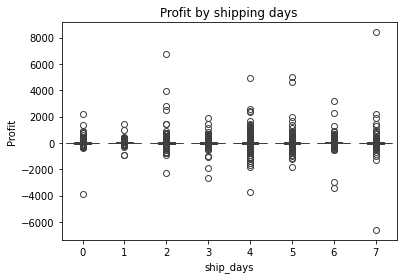

In [40]:
# Do ship days have any effect on the profit?

sns.boxplot(data=df, x="ship_days", y="Profit")
plt.title("Profit by shipping days")
plt.show()

In [41]:
df[["ship_days", "Profit"]].corr()

,ship_days,Profit
ship_days,1.000000,-0.004649
Profit,-0.004649,1.000000


In [42]:
df.groupby("Region")["ship_days"].mean()

Region
Central    4.058115
East       3.908708
South      3.958025
West       3.929753
Name: ship_days, dtype: float64

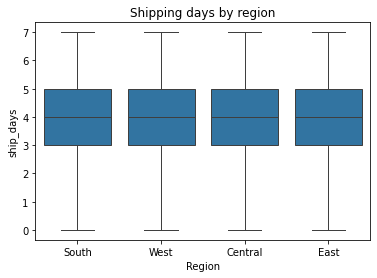

In [43]:
sns.boxplot(data=df, x="Region", y="ship_days")
plt.title("Shipping days by region")
plt.show()

In [44]:
df.groupby("City")["ship_days"].mean().sort_values()

City
Mentor            0.0
Kenner            0.0
Rock Hill         0.0
Portage           0.0
Billings          0.0
                 ... 
Oswego            7.0
Citrus Heights    7.0
Yucaipa           7.0
Norfolk           7.0
Waukesha          7.0
Name: ship_days, Length: 531, dtype: float64

In [45]:
df.groupby("Sub-Category").agg(
    avg_ship_days=("ship_days", "mean"),
    avg_profit=("Profit", "mean")
)

,avg_ship_days,avg_profit
Sub-Category,,
Accessories,3.886452,54.111788
Appliances,3.989270,38.922758
Art,4.054020,8.200737
Binders,4.022324,19.843574
Bookcases,3.811404,-15.230509
Chairs,3.899514,43.095894
Copiers,3.617647,817.909190
Envelopes,4.015748,27.418019
Fasteners,3.976959,4.375660


In [46]:
df.groupby("City").agg(
    avg_ship_days=("ship_days", "mean"),
    avg_profit=("Profit", "mean")
)

,avg_ship_days,avg_profit
City,,
Aberdeen,3.000000,6.630000
Abilene,2.000000,-3.758400
Akron,4.190476,-8.887410
Albuquerque,4.642857,45.292007
Alexandria,4.750000,19.913644
...,...,...
Woonsocket,3.000000,19.669775
Yonkers,4.200000,184.517047
York,4.400000,-20.433840


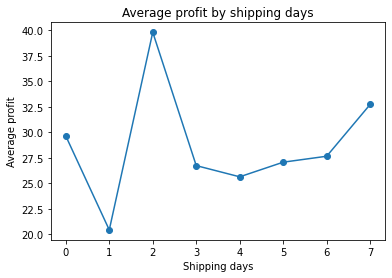

In [47]:
# The result is noisy. It doesn't seem to follow any significant trend. I did have fun though, if you count that as progress.

ship_summary = df.groupby("ship_days").agg(
    avg_profit=("Profit", "mean"),
    orders=("Profit", "count")
)

ship_summary["avg_profit"].plot(marker="o")
plt.title("Average profit by shipping days")
plt.xlabel("Shipping days")
plt.ylabel("Average profit")
plt.show()


## Shipping Time Conclusion

The hypothesis was that longer shipping times might negatively affect profit, either through customer dissatisfaction, returns, or operational inefficiency. The data does not support this.

Shipping days show near-zero correlation with profit, and the distribution of profit is consistent across all shipping day values. No sub-category or region shows a meaningful pattern between delivery time and profitability.

Ship mode also tells a similar story:

                avg_profit  total_profit  loss_rate  orders
Ship Mode                                                  
First Class      31.839948    48969.8399  19.050715    1538
Second Class     29.535545    57446.6354  15.784062    1945
Same Day         29.266591    15891.7589  18.047882     543
Standard Class   27.494770   164088.7875  19.654826    5968


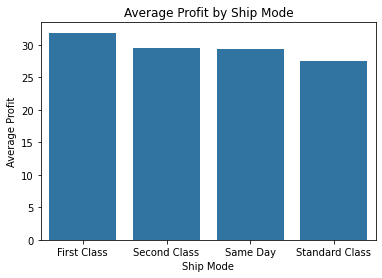

In [48]:
ship_mode_summary = df.groupby("Ship Mode").agg(
    avg_profit=("Profit", "mean"),
    total_profit=("Profit", "sum"),
    loss_rate=("Profit", lambda x: (x < 0).mean() * 100),
    orders=("Order ID", "count")
).sort_values("avg_profit", ascending=False)

print(ship_mode_summary)

sns.barplot(data=ship_mode_summary.reset_index(), x="Ship Mode", y="avg_profit")
plt.title("Average Profit by Ship Mode")
plt.xlabel("Ship Mode")
plt.ylabel("Average Profit")
plt.show()

# Time Series Analysis

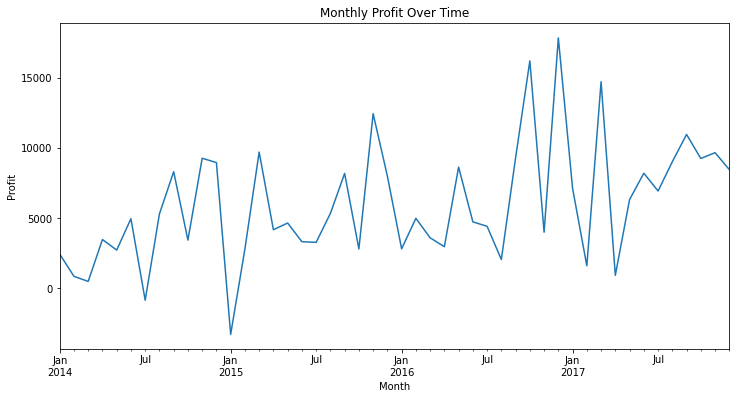

In [49]:
# Let's plot monthly profits.
# It seems like the profit overall is increasing, so the business is growing.
# However, there is some fluctuation, which isn't unusual.
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_profit = df.resample("M", on="Order Date")["Profit"].sum()

plt.figure(figsize=(12, 6))
monthly_profit.plot()
plt.xlabel("Month")
plt.ylabel("Profit")
plt.title("Monthly Profit Over Time")
plt.show()

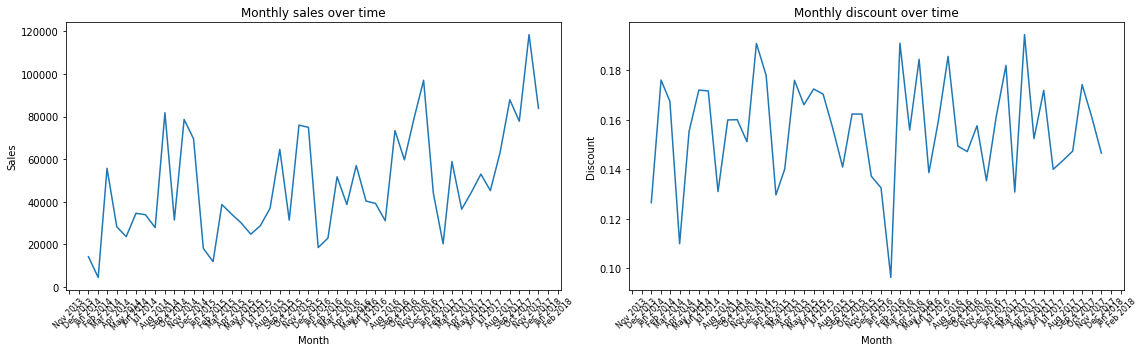

In [50]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = df.resample("MS", on="Order Date")["Sales"].sum()
monthly_discount = df.resample("MS", on="Order Date")["Discount"].mean()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(monthly_sales.index, monthly_sales.values)
axes[0].set_title("Monthly sales over time")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Sales")
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[0].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[0].tick_params(axis="x", labelsize=8)

axes[1].plot(monthly_discount.index, monthly_discount.values)
axes[1].set_title("Monthly discount over time")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Discount")
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=1))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[1].tick_params(axis="x", labelsize=8)

for ax in axes:
    plt.sca(ax)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [51]:
# Logically, sales follow discount. But, is there a reason discounts are in place at that time of year?
# I think I can use my common sense and a little knowledge of the UNIVERSE and suggest a hypothesis. Sorry, data. 
# We see that discounts are increased around the summer, which is logical considering the company sells office supplies.
# People are more relaxed during the summer. There's a school holiday, lots of vacations and some businesses tank.
# However, it might be more comfortable to buy the supplies when they at their cheapest.
# Well, it doesn't change much for us to say that this spike is human-made. Profit doesn't seem to be affected by the discount.

In [52]:
df["month_num"] = df["Order Date"].dt.month

monthly_pattern = df.groupby("month_num").agg(
    avg_sales=("Sales", "mean"),
    avg_profit=("Profit", "mean"),
    avg_discount=("Discount", "mean")
)

print(monthly_pattern)

            avg_sales  avg_profit  avg_discount
month_num                                      
1          249.146550   23.974924      0.149921
2          199.170838   34.315369      0.146233
3          294.548116   41.084321      0.155029
4          206.230731   17.346462      0.163129
5          210.923553   30.491575      0.165429
6          212.996763   29.687302      0.162817
7          207.377601   19.482626      0.157887
8          225.274877   30.845522      0.154235
9          222.451154   26.650380      0.148995
10         244.594609   38.808353      0.162601
11         239.606438   24.111779      0.158307
12         231.032318   30.801983      0.150433


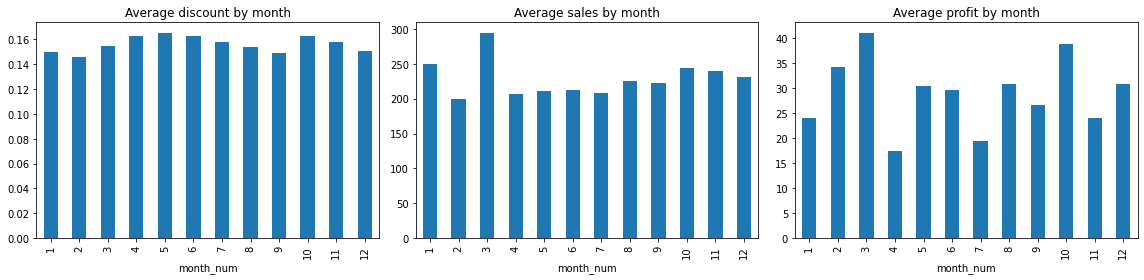

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

monthly_pattern["avg_discount"].plot(kind="bar", ax=axes[0], title="Average discount by month")
monthly_pattern["avg_sales"].plot(kind="bar", ax=axes[1], title="Average sales by month")
monthly_pattern["avg_profit"].plot(kind="bar", ax=axes[2], title="Average profit by month")

plt.tight_layout()
plt.show()

In [54]:
df["month_num"] = df["Order Date"].dt.month

monthly_totals = df.groupby("month_num").agg(
    total_sales=("Sales", "sum"),
    total_profit=("Profit", "sum"),
    total_orders=("Order ID", "count"),
    avg_discount=("Discount", "mean")
)

monthly_totals

,total_sales,total_profit,total_orders,avg_discount
month_num,,,,
1,94924.8356,9134.4461,381,0.149921
2,59751.2514,10294.6107,300,0.146233
3,205005.4888,28594.6872,696,0.155029
4,137762.1286,11587.4363,668,0.163129
5,155028.8117,22411.3078,735,0.165429
6,152718.6793,21285.7954,717,0.162817
7,147238.0970,13832.6648,710,0.157887
8,159044.0630,21776.9384,706,0.154235
9,307649.9457,36857.4753,1383,0.148995


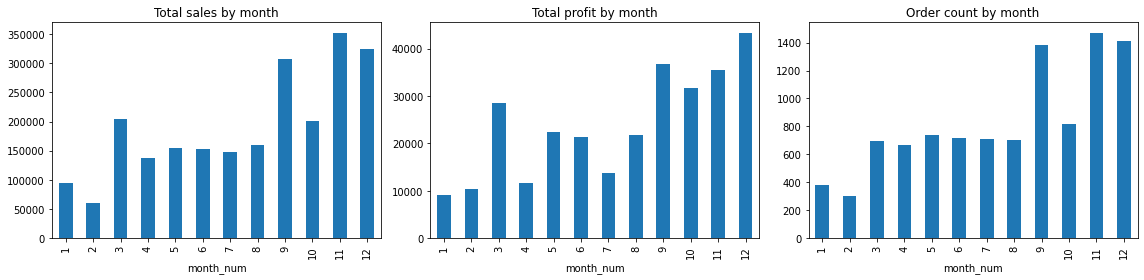

In [55]:
# Grouping months throughout the years shows us additional interesting information.
# March, September, November, and December look like some of the strongest months overall.
# They stand out more consistently across sales and profit, while discount stays relatively stable.
# That could mean these months are seasonally stronger for the business, rather than just boosted by discounts.

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

monthly_totals["total_sales"].plot(kind="bar", ax=axes[0], title="Total sales by month")
monthly_totals["total_profit"].plot(kind="bar", ax=axes[1], title="Total profit by month")
monthly_totals["total_orders"].plot(kind="bar", ax=axes[2], title="Order count by month")

plt.tight_layout()
plt.show()

What have we learnt?

- Higher discounts are generally associated with lower profit. However, the effect is noisy and may depend on the product or region.
- Some sub-categories generate consistent profit. Others show high loss rates and negative total profit.
- Some states contribute strongly to the total profit. Others show high loss rates even with decent order volume.
- High sales volume does not guarantee high profit. Some segments may rely heavily on discounting to generate revenue.
- Certain months (e.g., March, September, November, December) appear stronger. It is unclear whether this is driven by demand, discount strategy, or product mix


## Profitability Classification

The EDA identified discount, sub-category, and region as the strongest drivers of profitability. 
The next step is to formalize this into a binary classification problem: can we predict whether 
an order will be profitable based on order-level attributes alone?

We use a Random Forest classifier, which handles mixed feature types well and provides 
interpretable feature importance scores that we can compare against our EDA findings.

In [56]:
df["is_profitable"] = (df["Profit"] > 0).astype(int)

In [57]:
from sklearn.preprocessing import LabelEncoder

features = ["Sub-Category", "Region", "Segment", "Ship Mode", "Discount", "Quantity", "Sales"]

X = df[features].copy()
y = df["is_profitable"]

# Encode categoricals
cat_features = ["Sub-Category", "Region", "Segment", "Ship Mode"]
le = LabelEncoder()
for col in cat_features:
    X[col] = le.fit_transform(X[col])

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

              precision    recall  f1-score   support

           0       0.89      0.79      0.84       377
           1       0.95      0.98      0.96      1622

    accuracy                           0.94      1999
   macro avg       0.92      0.88      0.90      1999
weighted avg       0.94      0.94      0.94      1999



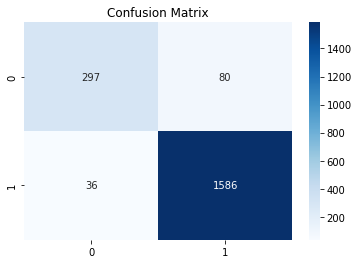

In [59]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

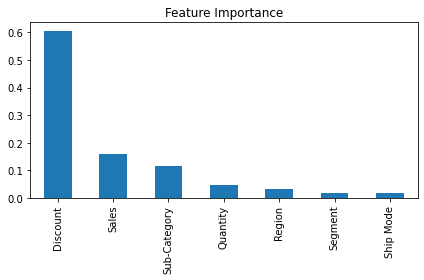

In [60]:
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
importance.plot(kind="bar", title="Feature Importance")
plt.tight_layout()
plt.show()

In [61]:
# Note: the dataset is imbalanced (~80% profitable orders).
# The model performs well overall but is weaker at identifying unprofitable orders (recall 0.79).
# For business use, this is the more critical class to get right.

## Conclusion

Profitability in this dataset is driven primarily by discount levels and product sub-category, 
with geography playing a secondary role. Tables and Bookcases are structurally unprofitable 
regardless of region. The Central region underperforms across multiple categories.

A Random Forest classifier trained on these features achieves 94% accuracy, confirming 
that profitability is largely predictable from order-level attributes alone.

Shipping time and ship mode have minimal impact on profit, contrary to initial expectations.

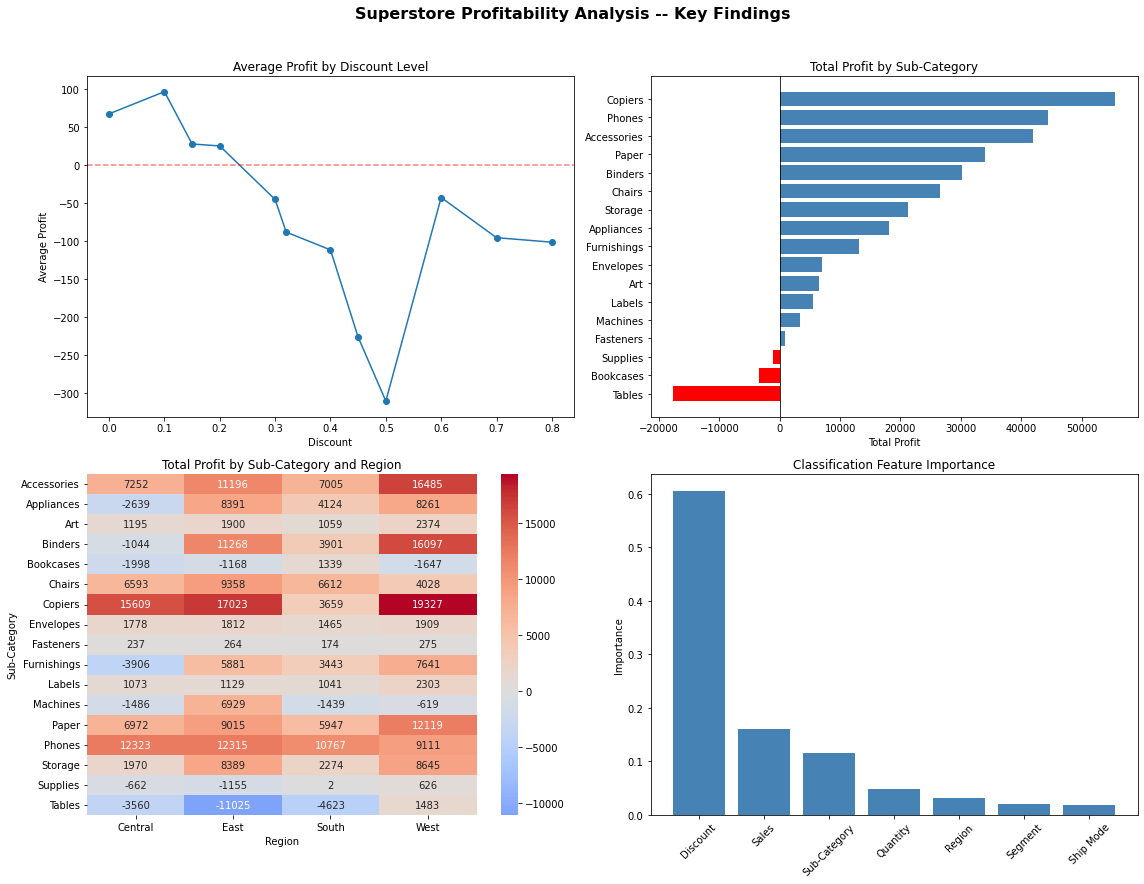

In [63]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Superstore Profitability Analysis -- Key Findings", fontsize=16, fontweight="bold", y=1.02)

# 1. Discount vs Profit
discount_profit = df.groupby("Discount")["Profit"].mean().reset_index()
axes[0, 0].plot(discount_profit["Discount"], discount_profit["Profit"], marker="o")
axes[0, 0].axhline(0, color="red", linestyle="--", alpha=0.5)
axes[0, 0].set_title("Average Profit by Discount Level")
axes[0, 0].set_xlabel("Discount")
axes[0, 0].set_ylabel("Average Profit")

# 2. Total profit by sub-category
subcat_profit = df.groupby("Sub-Category")["Profit"].sum().sort_values()
colors = ["red" if x < 0 else "steelblue" for x in subcat_profit.values]
axes[0, 1].barh(subcat_profit.index, subcat_profit.values, color=colors)
axes[0, 1].axvline(0, color="black", linewidth=0.8)
axes[0, 1].set_title("Total Profit by Sub-Category")
axes[0, 1].set_xlabel("Total Profit")

# 3. Region x Sub-Category heatmap
pivot = df.groupby(["Sub-Category", "Region"])["Profit"].sum().unstack()
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="coolwarm", center=0, ax=axes[1, 0])
axes[1, 0].set_title("Total Profit by Sub-Category and Region")

# 4. Feature importance
importance = pd.Series(model.feature_importances_, index=features).sort_values(ascending=False)
axes[1, 1].bar(importance.index, importance.values, color="steelblue")
axes[1, 1].set_title("Classification Feature Importance")
axes[1, 1].set_ylabel("Importance")
axes[1, 1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig("summary.png", dpi=150, bbox_inches="tight")
plt.show()